# Évaluation finale — Random Forest

Charge le modèle final sauvegardé par `train_final.ipynb` et l'évalue sur le jeu de test final. Le preprocessing vient de `preprocessing.ipynb` avec la vue test sans augmentation.

In [1]:
import gc, json, sys
from datetime import datetime
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             f1_score, precision_score, recall_score, roc_auc_score)

ROOT = Path.cwd().resolve()
while not (ROOT / "cross_validation.py").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from ipynb.fs.full.preprocessing import get_data_pipeline
from random_forest.hyperparameter_search import extract_hog_features, tensor_to_gray_image

FINAL_RESULTS_DIR = ROOT / "results" / "random_forest" / "final_model"
EVAL_DIR = ROOT / "results" / "random_forest" / "evaluation"
EVAL_DIR.mkdir(parents=True, exist_ok=True)

c:\Users\admin\git\repository\Zoidberg2.0\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Chargement du modèle final

In [2]:
with open(FINAL_RESULTS_DIR / "train_meta.json", encoding="utf-8") as f:
    meta = json.load(f)
cfg = meta["config"]
model = joblib.load(Path(meta["model_path"]))
scaler = joblib.load(Path(meta["scaler_path"]))
label_names = meta["label_names"]
print("Config du modèle final :")
print(json.dumps(cfg, indent=2))

Config du modèle final :
{
  "n_estimators": 300,
  "max_depth": null,
  "min_samples_split": 5,
  "min_samples_leaf": 1,
  "max_features": "sqrt",
  "criterion": "gini",
  "use_smote": true,
  "smote_k_neighbors": 3
}


## 2. Jeu de test final

In [3]:
pipeline = get_data_pipeline(augment=False)
test_view = pipeline["test_view"]
label_names = list(pipeline["label_names"].values())
print(f"Test set : {len(test_view)} images, classes = {label_names}")

X_test, y_test = extract_hog_features(test_view, desc="Test HOG")
X_test_scaled = scaler.transform(X_test)

Using the latest cached version of the dataset since PAR8/chest-xray-pneumonia couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at C:\Users\admin\.cache\huggingface\datasets\PAR8___chest-xray-pneumonia\default\0.0.0\42d3b32e6fc8f1c1974fd14f23bb49e7a130b801 (last modified on Thu Mar  5 10:49:38 2026).
c:\Users\admin\git\repository\Zoidberg2.0\.venv\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Test set : 624 images, classes = ['normal', 'bacteria', 'virus']


## 3. Prédictions et métriques

In [4]:
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)

metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, average="macro", zero_division=0),
    "recall": recall_score(y_test, y_pred, average="macro", zero_division=0),
    "f1": f1_score(y_test, y_pred, average="macro", zero_division=0),
}
try:
    metrics["roc_auc"] = roc_auc_score(y_test, y_proba, multi_class="ovr")
except ValueError:
    metrics["roc_auc"] = float("nan")

for k, v in metrics.items():
    print(f"{k:10s} {v:.4f}")

report = classification_report(y_test, y_pred, target_names=label_names, output_dict=True)
print("\n" + classification_report(y_test, y_pred, target_names=label_names))

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 300 out of 300 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.0s


accuracy   0.7131
precision  0.7477
recall     0.7141
f1         0.6972
roc_auc    0.9128

              precision    recall  f1-score   support

      normal       0.90      0.45      0.60       234
    bacteria       0.67      0.95      0.78       242
       virus       0.68      0.74      0.71       148

    accuracy                           0.71       624
   macro avg       0.75      0.71      0.70       624
weighted avg       0.76      0.71      0.70       624



[Parallel(n_jobs=8)]: Done 300 out of 300 | elapsed:    0.0s finished


## 4. Matrice de confusion

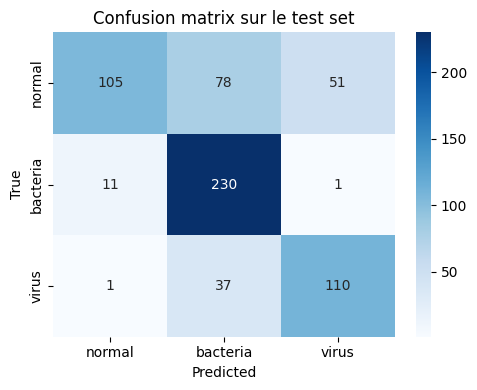

In [5]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion matrix sur le test set")
plt.tight_layout()
plt.savefig(EVAL_DIR / "confusion_matrix.png", dpi=150)
plt.show()

confusion_out = {
    "labels": label_names,
    "matrix": cm.tolist(),
}
with open(EVAL_DIR / "confusion_matrix.json", "w", encoding="utf-8") as f:
    json.dump(confusion_out, f, indent=2)

## 5. Bar-chart des métriques globales

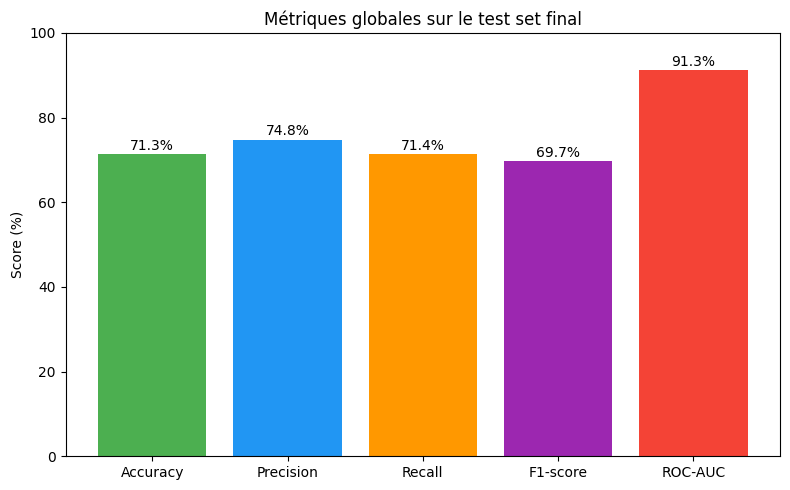

In [6]:
names = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
vals = [metrics["accuracy"], metrics["precision"], metrics["recall"], metrics["f1"], metrics["roc_auc"]]
pcts = [v * 100 for v in vals]
plt.figure(figsize=(8, 5))
plt.bar(names, pcts, color=["#4caf50", "#2196f3", "#ff9800", "#9c27b0", "#f44336"])
plt.ylabel("Score (%)"); plt.ylim(0, 100)
plt.title("Métriques globales sur le test set final")
for i, v in enumerate(pcts):
    plt.text(i, v + 1, f"{v:.1f}%", ha="center")
plt.tight_layout()
plt.savefig(EVAL_DIR / "metrics_bar.png", dpi=150)
plt.show()

metric_scores = [
    {"name": name, "score": float(value), "score_percent": float(value * 100)}
    for name, value in zip(names, vals)
]
with open(EVAL_DIR / "metric_scores.json", "w", encoding="utf-8") as f:
    json.dump(metric_scores, f, indent=2)

## 6. Exemples qualitatifs

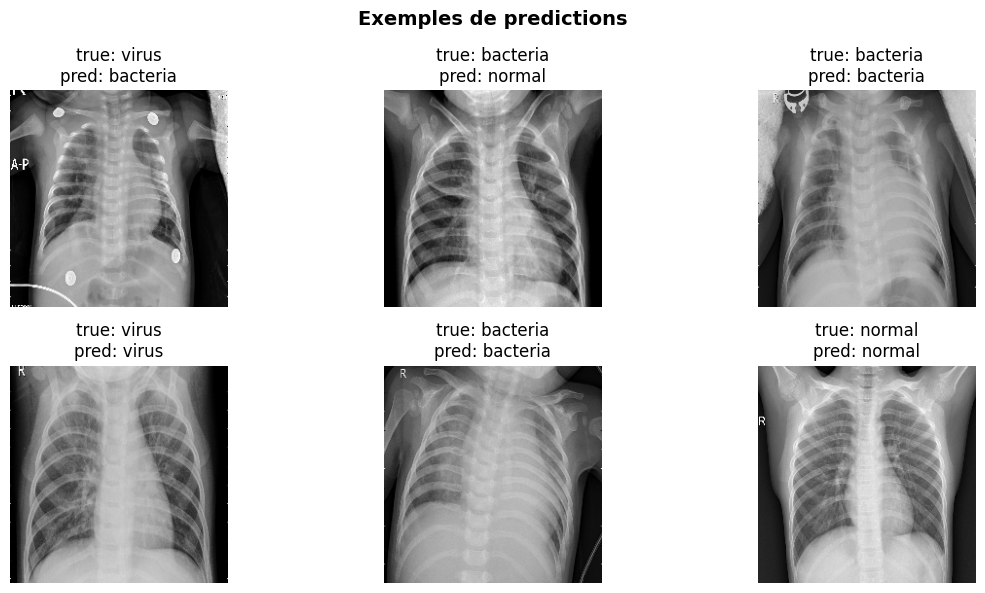

In [7]:
rng = np.random.default_rng(42)
sample_indices = rng.choice(len(test_view), size=min(6, len(test_view)), replace=False)
sample_predictions = []
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()
for ax, idx in zip(axes, sample_indices):
    sample = test_view[int(idx)]
    gray = tensor_to_gray_image(sample["image"])
    pred = y_pred[int(idx)]
    true = sample["label"]
    ax.imshow(gray, cmap="gray")
    ax.axis("off")
    ax.set_title(f"true: {label_names[true]}\npred: {label_names[pred]}")
    sample_predictions.append({
        "index": int(idx),
        "true_label": int(true),
        "true_class": label_names[int(true)],
        "pred_label": int(pred),
        "pred_class": label_names[int(pred)],
        "probabilities": {label_names[i]: float(y_proba[int(idx), i]) for i in range(len(label_names))},
    })
plt.suptitle("Exemples de predictions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(EVAL_DIR / "predictions.png", dpi=150)
plt.show()

with open(EVAL_DIR / "predictions.json", "w", encoding="utf-8") as f:
    json.dump(sample_predictions, f, indent=2)

## 7. Sauvegarde des métriques

In [8]:
out = {
    "model": "RandomForestClassifier",
    "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "config": cfg,
    "augmentation": False,
    "test_size": int(len(test_view)),
    "metrics": metrics,
    "classification_report": report,
    "confusion_matrix": cm.tolist(),
    "json_outputs": [
        "metrics.json",
        "confusion_matrix.json",
        "metric_scores.json",
        "predictions.json",
    ],
    "image_outputs": [
        "confusion_matrix.png",
        "metrics_bar.png",
        "predictions.png",
    ],
}
with open(EVAL_DIR / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(out, f, indent=2)
print(f"Sauvegardé : {EVAL_DIR / 'metrics.json'}")

del model, scaler
gc.collect()

Sauvegardé : C:\Users\admin\git\repository\Zoidberg2.0\results\random_forest\evaluation\metrics.json


7752